In [2]:
import re, json, warnings, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)

# --- DATA PATH ---
CSV_PATH = "sl_startup.csv"  # must have Description, Category, Location

# --- Columns ---
TEXT_COL   = "Description"
LABEL_CAT  = "Category"
LABEL_LOC  = "Location"
SUGG_COL   = "Suggestion"   # optional; if absent, it's fine

# --- Domain words to keep (never stopworded) ---
DOMAIN_KEEP_WORDS = {
    "startup","startups","funding","seed","series","saas","subscription","api",
    "ai","ml","nlp","fintech","edtech","healthtech","ecommerce","marketplace",
    "b2b","b2c","sme","colombo","kandy","galle","sri","lanka",
    "retail","store","stores","shop","shops","boutique","apparel","fashion","clothing",
    "footwear","sneakers","mobile","electronics","stationery","toy","pet","florist",
    "cafe","cafes","coffee","restaurant","restaurants","bistro","bakery","patisserie",
    "grocery","supermarket","minimart","mini","mart","butcher","seafood","vegetable",
    "gym","fitness","studio","salon","spa","barbershop","barber",
    "pharmacy","clinic","hospital","courier","delivery","logistics","coworking","workspace"
}

# --- Simple location rule ---
DISTRICTS = [
    "Colombo","Gampaha","Kalutara","Kandy","Matale","Nuwara Eliya","Galle","Matara","Hambantota",
    "Jaffna","Kilinochchi","Mannar","Vavuniya","Mullaitivu","Batticaloa","Ampara","Trincomalee",
    "Kurunegala","Puttalam","Anuradhapura","Polonnaruwa","Badulla","Monaragala","Ratnapura","Kegalle"
]
_DISTRICT_PATTERNS = {d: re.compile(rf"\b{re.escape(d.lower())}\b", re.IGNORECASE) for d in DISTRICTS}
_DISTRICT_CANON    = {d.lower(): d for d in DISTRICTS}

ONLINE_KEYWORDS = [
    "online","web","internet","ecommerce","e-commerce","saas","cloud","virtual","remote",
    "app","platform","marketplace","digital","lms","subscription","software as a service","online-only"
]
_ONLINE_PATTERNS = [re.compile(rf"\b{re.escape(w)}\b", re.IGNORECASE) for w in ONLINE_KEYWORDS]

def infer_location_simple(text: str):
    """Return explicit district if found; else 'Online' if online-ish; else None."""
    s = (text or "").lower()
    for d, pat in _DISTRICT_PATTERNS.items():
        if pat.search(s):
            return _DISTRICT_CANON[d.lower()]
    for pat in _ONLINE_PATTERNS:
        if pat.search(s):
            return "Online"
    return None

# --- Load data ---
df = pd.read_csv(CSV_PATH)
assert TEXT_COL in df.columns, f"CSV must include '{TEXT_COL}'"
for c in [LABEL_CAT, LABEL_LOC]:
    assert c in df.columns, f"CSV must include '{c}'"

print("Rows:", len(df))
print("Columns:", list(df.columns))

# split (stratify by Category)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[LABEL_CAT].astype(str)
)
len(train_df), len(test_df)


Rows: 10000
Columns: ['Description', 'Category', 'Subcategory', 'Location', 'Suggestion']


(8000, 2000)

In [3]:
class SafeSpellCorrector:
    def __init__(self):
        self.mode = "none"
        self.symspell = None
        try:
            from symspellpy import SymSpell, Verbosity  # type: ignore
            self.symspell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
            freq_path = Path("frequency_dictionary_en_82_765.txt")
            if freq_path.exists():
                self.symspell.load_dictionary(str(freq_path), term_index=0, count_index=1)
            self._verbosity = Verbosity.CLOSEST
            self.mode = "symspell"
        except Exception:
            try:
                from textblob import TextBlob  # type: ignore
                self.mode = "textblob"
            except Exception:
                pass

    def __call__(self, text: str) -> str:
        if not text or self.mode == "none":
            return text
        if self.mode == "symspell" and self.symspell is not None:
            toks = re.findall(r"[A-Za-z][A-Za-z\-']+", text)
            out = []
            for w in toks:
                if len(w) < 5:
                    out.append(w); continue
                sug = self.symspell.lookup(w, self._verbosity, max_edit_distance=2)
                out.append(sug[0].term if sug else w)
            return " ".join(out)
        if self.mode == "textblob":
            try:
                from textblob import TextBlob  # type: ignore
                return str(TextBlob(text).correct())
            except Exception:
                return text
        return text

SYNONYM_MAP = {
    r"\bgen(?:erative)?\s*ai\b": "artificial intelligence",
    r"\bai\b": "artificial intelligence",
    r"\bml\b": "machine learning",
    r"\bnlp\b": "natural language processing",
    r"\bsaas\b": "software as a service",
    r"\be-?commerce\b": "ecommerce",
    r"\bfin-?tech\b": "fintech",
    r"\bed-?tech\b": "edtech",
    r"\bhealth-?tech\b": "healthtech",
}

PHRASE_EXPANSIONS = [
    (r"\b(internet\s*cafe)\b",                 "internet restaurants cafes quick service"),
    (r"\b(cafe|coffee\s*shop|coffeehouse|tea\s*shop)\b",
                                              "restaurants cafes quick service food beverage"),
    (r"\b(bakery|patisserie|bakeshop)\b",      "restaurants cafes bakery food beverage"),
    (r"\b(bistro|eatery|diner)\b",             "restaurants cafes food beverage"),
    (r"\b(catering\s*(company|service|services))\b",
                                              "food beverage catering services"),
    (r"\b(clothing\s*store|apparel\s*shop|fashion\s*store|boutique)\b",
                                              "apparel fashion retail stores"),
    (r"\b(footwear\s*store|shoe\s*shop|sneaker\s*store)\b",
                                              "apparel fashion retail stores"),
    (r"\b(furniture\s*store|furnishing\s*store)\b",
                                              "furniture retail stores"),
    (r"\b(electronics\s*(shop|store)|mobile\s*(phone|device)\s*(shop|store))\b",
                                              "consumer electronics retail stores"),
    (r"\b(book\s*store|bookshop)\b",           "publishing retail stores"),
    (r"\b(stationery\s*(shop|store))\b",       "business supplies and equipment retail stores"),
    (r"\b(grocery\s*store|minimart|mini\s*mart|provision\s*store|kade)\b",
                                              "supermarkets retail stores food beverage"),
    (r"\b(super\s*market|supermarket)\b",      "supermarkets retail stores"),
    (r"\b(toy\s*store)\b",                     "consumer goods retail stores"),
    (r"\b(pet\s*shop|pet\s*store)\b",          "pets and animals retail stores"),
    (r"\b(florist|flower\s*shop)\b",           "arts and crafts retail stores"),
    (r"\b(butcher)\b",                         "food beverages retail stores"),
    (r"\b(seafood\s*shop|fish\s*monger)\b",    "food beverages retail stores"),
    (r"\b(vegetable\s*shop|greens\s*store)\b", "food beverages retail stores"),
    (r"\b(gym|fitness\s*centre|fitness\s*center|fitness\s*studio|health\s*club)\b",
                                              "sports fitness health wellness and fitness"),
    (r"\b(salon|barbershop|barber\s*shop|spa)\b",
                                              "beauty personal care services"),
    (r"\b(pharmacy|drug\s*store|drugstore)\b",
                                              "pharmaceuticals medical practice clinics"),
    (r"\b(hospital|clinic)\b",                 "hospital health care clinics"),
    (r"\b(car\s*dealership|auto\s*dealer|showroom)\b",
                                              "automotive dealerships"),
    (r"\b(car\s*repair|auto\s*repair|mechanic|service\s*center)\b",
                                              "automotive repair maintenance"),
    (r"\b(courier|delivery\s*service|delivery\s*company)\b",
                                              "package freight delivery logistics last mile delivery"),
    (r"\b(logistics\s*company|third[-\s]*party\s*logistics|3pl)\b",
                                              "logistics warehousing last mile delivery"),
    (r"\b(co-?working|coworking|shared\s*office|workspace)\b",
                                              "executive office services"),
    (r"\b(restaurant[s]?)\b",                  "restaurants cafes"),
    (r"\b(hardware\s*store|ironmongery)\b",    "building materials retail stores"),
]

class TextNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self, do_spell: bool = False, apply_synonyms: bool = True):
        self._spell = SafeSpellCorrector() if do_spell else None
        self.apply_synonyms = apply_synonyms
        self._lemmatizer = None
        try:
            import nltk
            from nltk.stem import WordNetLemmatizer  # type: ignore
            self._lemmatizer = WordNetLemmatizer()
        except Exception:
            self._lemmatizer = None
        self._stopwords = self._build_stopwords()

    def _build_stopwords(self) -> set:
        sw = set()
        try:
            import nltk
            from nltk.corpus import stopwords  # type: ignore
            try:
                sw = set(stopwords.words("english"))
            except LookupError:
                nltk.download("stopwords", quiet=True)
                sw = set(stopwords.words("english"))
        except Exception:
            sw = {"the","and","is","am","are","was","were","be","been","to","of","in","for","on","with",
                  "at","by","an","a","as","or","from","that","this","it","we","you"}
        return {w for w in sw if w not in DOMAIN_KEEP_WORDS}

    def _lemmatize(self, token: str) -> str:
        if self._lemmatizer is None: return token
        try: return self._lemmatizer.lemmatize(token)
        except Exception: return token

    def _apply_synonyms(self, text: str) -> str:
        if not self.apply_synonyms: return text
        out = text
        for pat, repl in SYNONYM_MAP.items():
            out = re.sub(pat, repl, out, flags=re.IGNORECASE)
        return out

    def _expand_phrases(self, text: str) -> str:
        adds = []
        for pat, expansion in PHRASE_EXPANSIONS:
            if re.search(pat, text, flags=re.IGNORECASE):
                adds.append(expansion)
        return text + (" " + " ".join(adds) if adds else "")

    def fit(self, X, y=None): return self

    def transform(self, X):
        processed = []
        for txt in X:
            s = (txt or "").strip().lower()
            s = self._apply_synonyms(s)
            s = self._expand_phrases(s)
            if self._spell is not None: s = self._spell(s)
            toks = re.findall(r"[a-z][a-z\-']+", s)
            toks = [t for t in toks if (t not in self._stopwords) or (t in DOMAIN_KEEP_WORDS)]
            toks = [self._lemmatize(t) for t in toks]
            processed.append(" ".join(toks))
        return np.array(processed, dtype=object)


In [4]:
class STEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """
    Balanced-speed embedding backend:
    - Tries ONNX Runtime via Optimum (fast on CPU)
    - Falls back to sentence-transformers
    - Falls back to TF-IDF + SVD (compact 256-dim) if both unavailable
    """
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2", svd_dim=256):
        self.model_name = model_name
        self.svd_dim = svd_dim
        self.backend = "none"      # "onnx" | "sbert" | "svd" | "none"
        self.tokenizer = None
        self.model = None
        self.dim_ = 0
        self._tfidf = None
        self._svd = None

    def fit(self, X, y=None):
        texts = list(X) if not isinstance(X, list) else X
        # 1) Try ONNX via Optimum
        try:
            from transformers import AutoTokenizer
            from optimum.onnxruntime import ORTModelForFeatureExtraction
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = ORTModelForFeatureExtraction.from_pretrained(self.model_name, export=True)
            import numpy as np, torch
            tokens = self.tokenizer(["hello"], return_tensors="pt", padding=True, truncation=True)
            with torch.no_grad():
                out = self.model(**tokens)
                vec = out.last_hidden_state.mean(dim=1).cpu().numpy()
            self.dim_ = int(vec.shape[1])
            self.backend = "onnx"
            return self
        except Exception:
            pass

        # 2) sentence-transformers fallback
        try:
            from sentence_transformers import SentenceTransformer
            self.model = SentenceTransformer(self.model_name)
            v = self.model.encode(["hello"], show_progress_bar=False, normalize_embeddings=True)
            self.dim_ = int(v.shape[1]) if hasattr(v, "shape") and len(v.shape) > 1 else len(v)
            self.backend = "sbert"
            return self
        except Exception:
            pass

        # 3) TF-IDF + SVD fallback
        try:
            from sklearn.feature_extraction.text import TfidfVectorizer
            from sklearn.decomposition import TruncatedSVD
            self._tfidf = TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=2, max_df=0.9)
            Xtf = self._tfidf.fit_transform(texts)
            self._svd = TruncatedSVD(n_components=self.svd_dim, random_state=42)
            Xsvd = self._svd.fit_transform(Xtf)
            self.dim_ = Xsvd.shape[1]
            self.backend = "svd"
            return self
        except Exception:
            self.backend = "none"
            self.dim_ = 0
            return self

    def transform(self, X):
        import numpy as np
        texts = list(X)
        if self.backend == "onnx":
            import torch
            all_vecs = []
            for i in range(0, len(texts), 64):
                batch = texts[i:i+64]
                tokens = self.tokenizer(batch, return_tensors="pt", padding=True, truncation=True)
                with torch.no_grad():
                    out = self.model(**tokens)
                    vec = out.last_hidden_state.mean(dim=1).cpu().numpy()
                norms = np.linalg.norm(vec, axis=1, keepdims=True) + 1e-12
                all_vecs.append(vec / norms)
            return np.vstack(all_vecs).astype(np.float32)

        if self.backend == "sbert":
            E = self.model.encode(texts, show_progress_bar=False, normalize_embeddings=True)
            return np.asarray(E, dtype=np.float32)

        if self.backend == "svd":
            Xtf = self._tfidf.transform(texts)
            Xsvd = self._svd.transform(Xtf)
            norms = np.linalg.norm(Xsvd, axis=1, keepdims=True) + 1e-12
            return (Xsvd / norms).astype(np.float32)

        return np.zeros((len(texts), max(self.dim_, 1)), dtype=np.float32)


In [5]:
# Shared featurizer (compute once, reuse)
featurizer = Pipeline([
    ("norm", TextNormalizer(do_spell=False)),
    ("feats", FeatureUnion(
        [("w_tfidf", TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2), min_df=2, max_df=0.9)),
         ("c_tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=2, max_df=0.9)),
         ("emb", STEmbeddingTransformer())],
        transformer_weights={"w_tfidf":1.0,"c_tfidf":0.5,"emb":1.0}
    ))
])

# Fit encoders + featurizer
enc_cat = LabelEncoder()
enc_loc = LabelEncoder()

X_train = train_df[TEXT_COL].astype(str).fillna("")
y_cat = enc_cat.fit_transform(train_df[LABEL_CAT].astype(str).fillna("NA"))
y_loc = enc_loc.fit_transform(train_df[LABEL_LOC].astype(str).fillna("NA"))

featurizer.fit(X_train)
X_vec = featurizer.transform(X_train)

# Train separate heads
cat_head = LogisticRegression(max_iter=2500, solver="saga", class_weight="balanced")
loc_head = LogisticRegression(max_iter=2500, solver="saga", class_weight="balanced")
cat_head.fit(X_vec, y_cat)
loc_head.fit(X_vec, y_loc)


LogisticRegression(class_weight='balanced', max_iter=2500, solver='saga')

In [8]:
# Extract embeddings for ANN (Balanced design)
X_norm = featurizer.named_steps["norm"].transform(X_train)
emb = dict(featurizer.named_steps["feats"].transformer_list)["emb"]  # the STEmbeddingTransformer
E = emb.transform(X_norm).astype(np.float32)  # [N, dim], L2-normalized inside transformer

import hnswlib
ann = hnswlib.Index(space='cosine', dim=E.shape[1])
ann.init_index(max_elements=E.shape[0], ef_construction=100, M=32)
ann.add_items(E, ids=np.arange(E.shape[0]))
ann.set_ef(50)  # query-time accuracy/speed tradeoff (higher = better recall)



[Category] macro-F1=1.0000 | acc=1.0000
                                      precision    recall  f1-score   support

                         Agriculture     1.0000    1.0000    1.0000        13
                Arts & Entertainment     1.0000    1.0000    1.0000        14
              Beauty & Personal Care     1.0000    1.0000    1.0000        12
                           Education     1.0000    1.0000    1.0000        14
                Energy & Environment     1.0000    1.0000    1.0000        12
                              Events     1.0000    1.0000    1.0000        12
                 Finance & Insurance     1.0000    1.0000    1.0000        11
                     Food & Beverage     1.0000    1.0000    1.0000        10
                   Health & Wellness     1.0000    1.0000    1.0000        12
                           Logistics     1.0000    1.0000    1.0000        13
                       Manufacturing     1.0000    1.0000    1.0000        13
              Media & 

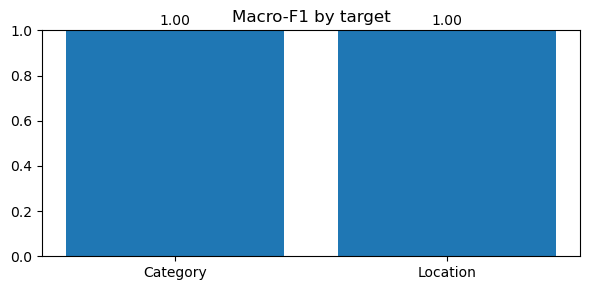

{'Category': {'macro_f1': 1.0,
  'accuracy': 1.0,
  'report': '                                      precision    recall  f1-score   support\n\n                         Agriculture     1.0000    1.0000    1.0000        13\n                Arts & Entertainment     1.0000    1.0000    1.0000        14\n              Beauty & Personal Care     1.0000    1.0000    1.0000        12\n                           Education     1.0000    1.0000    1.0000        14\n                Energy & Environment     1.0000    1.0000    1.0000        12\n                              Events     1.0000    1.0000    1.0000        12\n                 Finance & Insurance     1.0000    1.0000    1.0000        11\n                     Food & Beverage     1.0000    1.0000    1.0000        10\n                   Health & Wellness     1.0000    1.0000    1.0000        12\n                           Logistics     1.0000    1.0000    1.0000        13\n                       Manufacturing     1.0000    1.0000    1.000

In [9]:
def evaluate_heads(featurizer, cat_head, loc_head, enc_cat, enc_loc, test_df, max_cm_classes=40):
    Xtest = test_df[TEXT_COL].astype(str).fillna("")
    Xv = featurizer.transform(Xtest)

    # Category
    y_true_cat = enc_cat.transform(test_df[LABEL_CAT].astype(str).fillna("NA"))
    y_pred_cat = cat_head.predict(Xv)

    # Location (raw head, before simple rule override)
    y_true_loc = enc_loc.transform(test_df[LABEL_LOC].astype(str).fillna("NA"))
    y_pred_loc = loc_head.predict(Xv)

    metrics = {}
    # Cat metrics
    f1c  = f1_score(y_true_cat, y_pred_cat, average="macro")
    accc = accuracy_score(y_true_cat, y_pred_cat)
    repc = classification_report(y_true_cat, y_pred_cat,
                                 labels=np.arange(len(enc_cat.classes_)),
                                 target_names=list(enc_cat.classes_),
                                 digits=4, zero_division=0)
    metrics["Category"] = {"macro_f1": float(f1c), "accuracy": float(accc), "report": repc}

    # Loc metrics
    f1l  = f1_score(y_true_loc, y_pred_loc, average="macro")
    accl = accuracy_score(y_true_loc, y_pred_loc)
    repl = classification_report(y_true_loc, y_pred_loc,
                                 labels=np.arange(len(enc_loc.classes_)),
                                 target_names=list(enc_loc.classes_),
                                 digits=4, zero_division=0)
    metrics["Location"] = {"macro_f1": float(f1l), "accuracy": float(accl), "report": repl}

    # Print summaries
    for k in ["Category","Location"]:
        print(f"\n[{k}] macro-F1={metrics[k]['macro_f1']:.4f} | acc={metrics[k]['accuracy']:.4f}")
        print(metrics[k]["report"])

    # Summary bar
    labels = list(metrics.keys())
    macro_f1s = [metrics[k]["macro_f1"] for k in labels]
    plt.figure(figsize=(6,3))
    plt.bar(labels, macro_f1s)
    plt.ylim(0, 1)
    plt.title("Macro-F1 by target")
    for i, v in enumerate(macro_f1s):
        plt.text(i, v+0.01, f"{v:.2f}", ha="center", va="bottom")
    plt.tight_layout(); plt.show()

    return metrics

metrics = evaluate_heads(featurizer, cat_head, loc_head, enc_cat, enc_loc, test_df)
metrics


In [10]:
def _article_for(word: str) -> str:
    w = (word or "").strip().lower()
    if not w: return "a"
    if re.match(r"^(honest|hour|heir)\b", w): return "an"
    if re.match(r"^(ai|api|ml|nlp|lms|sme|mba)\b", w): return "an"
    return "an" if w[0] in "aeiou" else "a"

_PLAYBOOKS = {
    "apparel & fashion": {
        "narrative": [
            "Lead with a tight capsule collection and crystal-clear sizing/fit to reduce returns.",
            "Win on story and community: style guides, try-on reels, and campus/micro-creator collabs."
        ],
        "ops": [
            "Start with 15–25 SKUs; reorder fast movers weekly; avoid deep inventory.",
            "Offer easy exchanges, WhatsApp support, and COD where feasible."
        ],
        "pricing": "Aim for 2.2×–2.8× landed-cost markup; test bundles (top+bottom) for AOV lift.",
        "kpis": [
            ("Email list signups (90d)", 300),
            ("First 30-day orders", 80),
            ("Average order value (LKR)", 4500),
            ("Gross margin %", 55),
            ("Return rate % (≤ target)", 8),
            ("Repeat rate (90d)", 25)
        ]
    },
    "food & beverages": {
        "narrative": [
            "Keep the menu small and operationally simple; build around 2–3 hero items.",
            "Design for delivery: packaging and prep times matter."
        ],
        "ops": [
            "Pilot as pop-ups/ghost kitchen; standardize recipes; track prep time and waste.",
            "Partner with delivery apps; upsell combos and add-ons."
        ],
        "pricing": "Keep COGS under 30–35% and food-cost variance under 5%.",
        "kpis": [("Preorders/day by week 4", 20), ("Gross margin", 65), ("Avg. rating", 4.5)]
    },
    "retail": {
        "narrative": [
            "Anchor on one clear value proposition (price, convenience, curation, or service).",
            "Own a narrow niche first; expand after repeat purchase becomes predictable."
        ],
        "ops": [
            "Pilot with 50–100 customers; loyalty/referrals on day one.",
            "Measure basket size, repeat rate, and category adjacencies."
        ],
        "pricing": "Bundle to raise AOV; maintain 45–60% gross margins depending on category.",
        "kpis": [("Repeat rate (60d)", 30), ("AOV (target LKR)", 4000), ("NPS", 45)]
    },
    "default": {
        "narrative": [
            "Ship a narrow MVP for one painful job; defer nice-to-haves.",
            "Recruit 5–10 design partners; co-create roadmap in exchange for early access."
        ],
        "ops": [
            "Weekly build-measure-learn cadence; Friday demos.",
            "Simple analytics: activation, retention, CAC, payback."
        ],
        "pricing": "Start simple (one plan + intro discount); add tiers post-PMF signals.",
        "kpis": [("Activation rate", 35), ("Weekly retention (W4)", 30), ("Payback (months)", 6)]
    }
}

def _playbook_for(category: str):
    cat = (category or "").strip().lower()
    if cat in _PLAYBOOKS: return _PLAYBOOKS[cat]
    if "apparel" in cat or "fashion" in cat: return _PLAYBOOKS["apparel & fashion"]
    if "food" in cat or "beverage" in cat:   return _PLAYBOOKS["food & beverages"]
    if "retail" in cat:                      return _PLAYBOOKS["retail"]
    return _PLAYBOOKS["default"]

def _signals_from_text(text: str, category: str, location: str) -> dict:
    s = (text or "").lower()
    loc_override = infer_location_simple(text)
    is_online = (loc_override == "Online")
    district = None if is_online or (loc_override is None) else loc_override
    sig = {"is_online": is_online, "audience": [], "product": None, "channels": [], "district": district}
    if re.search(r"\byoung adult[s]?\b|\byouth\b|\bteen[s]?\b", s): sig["audience"].append("young adults")
    if re.search(r"\bstudent[s]?\b|\buni(?:versity)?\b", s):        sig["audience"].append("students")
    if re.search(r"\b(women|ladies)\b", s):                         sig["audience"].append("women")
    if re.search(r"\b(men|gents)\b", s):                            sig["audience"].append("men")
    if re.search(r"\bkid[s]?\b|\bchildren\b", s):                   sig["audience"].append("kids")
    if re.search(r"\b(cafe|coffee|bakery|bistro|restaurant)\b", s): sig["product"] = "cafe/restaurant"
    elif re.search(r"\b(clothing|apparel|boutique|fashion|footwear|sneaker)\b", s): sig["product"] = "apparel store"
    elif re.search(r"\b(grocery|supermarket|minimart)\b", s):       sig["product"] = "grocery"
    elif re.search(r"\b(salon|spa|barber)\b", s):                   sig["product"] = "salon/spa"
    elif re.search(r"\b(gym|fitness)\b", s):                        sig["product"] = "gym/fitness"
    elif re.search(r"\b(courier|delivery|3pl|logistics)\b", s):     sig["product"] = "delivery/logistics"
    else:
        sig["product"] = category or "business"
    if is_online:
        sig["channels"].extend(["Instagram", "TikTok", "Facebook", "SEO", "WhatsApp"])
    if sig["product"] in ("cafe/restaurant","grocery","apparel store","salon/spa","gym/fitness"):
        sig["channels"].extend(["Google Maps", "Local influencers", "Flyers near footfall hotspots"])
    sig["audience"] = list(dict.fromkeys(sig["audience"]))
    sig["channels"] = list(dict.fromkeys(sig["channels"]))
    return sig

def _compose_narrative(text: str, category: str, sig: dict) -> str:
    pb  = _playbook_for(category)
    aud = f" for {', '.join(sig['audience'])}" if sig["audience"] else ""
    loc = "online" if sig["is_online"] else (sig["district"] or "your area")
    article = _article_for(sig.get("product") or "business")
    p1 = (f"You’re building {article} {sig['product']} in the **{category}** space{aud}. "
          f"Start by clarifying a sharp value proposition and launching in {loc}. ")
    p1 += " ".join(pb["narrative"])
    ch = ""
    if sig["channels"]:
        ch = " Prioritize channels you can execute now: " + ", ".join(sig["channels"][:4]) + "."
    ops = " ".join(pb["ops"]).replace("menu","collection").replace("menus","collections") \
                              .replace("merchandising/menu", "visual merchandising/collection")
    p2 = " On operations: " + ops + ch
    p3 = f" Pricing: {pb['pricing']}"
    return p1 + "\n\n" + p2 + "\n\n" + p3

def _roadmap_90d(sig: dict) -> list[dict]:
    if (sig.get("product") == "apparel store"):
        if sig["is_online"]:
            phase1 = ["Interview 15–20 target shoppers; collect 150+ emails/DMs via landing page.",
                      "Source 15–25 SKUs (capsule); size chart & try-on content ready."]
            phase2 = ["Soft launch: Instagram Shop/website live; test 2–3 creator collabs.",
                      "Track AOV, add a bundle (top+bottom); optimize returns workflow."]
            phase3 = ["Scale winners; reorder weekly; introduce loyalty/referrals and limited drops."]
        else:
            phase1 = ["Scout pop-up/low-rent spaces; run a 1–2 day pop-up; capture 100+ contacts.",
                      "Finalize capsule collection + visual merchandising plan."]
            phase2 = ["Soft launch with limited hours; collect Google/Meta reviews; iterate display & sizing guides.",
                      "Negotiate suppliers/MOQs; introduce a first-order exchange guarantee."]
            phase3 = ["Expand hours/SKUs; add bundles/subscriptions (styling packs); run campus promos."]
        return [{"phase":"Weeks 1–2","goals":phase1},
                {"phase":"Weeks 3–6","goals":phase2},
                {"phase":"Weeks 7–12","goals":phase3}]
    if sig["is_online"]:
        phase1 = ["Validate demand with 20–30 problem interviews and a no-code waitlist.",
                  "Set up Instagram + WhatsApp inbox; collect 100+ contacts."]
        phase2 = ["Ship MVP (catalog/ordering/booking).",
                  "Run 2–3 creator collabs; measure CTR→signup and first purchase."]
        phase3 = ["Double-down on winning channel; optimize onboarding; add loyalty/referrals."]
    else:
        phase1 = ["Scout locations or pop-up partners; estimate footfall and rent/revenue-share.",
                  "Pilot a 1–2 day pop-up; capture 100+ contacts via QR + incentive."]
        phase2 = ["Standardize suppliers/SOPs; soft-launch with clear hours/inventory.",
                  "Collect reviews (Google/Meta) and iterate visual merchandising."]
        phase3 = ["Negotiate better MOQs; expand SKUs or hours; introduce bundles/subscriptions."]
    return [{"phase":"Weeks 1–2","goals":phase1},
            {"phase":"Weeks 3–6","goals":phase2},
            {"phase":"Weeks 7–12","goals":phase3}]

def _kpis(category: str, sig: dict) -> list[dict]:
    pb = _playbook_for(category)
    out = [{"name": k, "target": v} for (k, v) in pb["kpis"]]
    out.insert(0, {"name": "Problem interviews completed", "target": 20})
    if sig["is_online"]:
        out.append({"name": "Email/DM list (90d)", "target": 500})
        out.append({"name": "CAC payback (months)", "target": 6})
    else:
        out.append({"name": "Footfall/day by week 8", "target": 60})
    return out[:6]

def _risks(category: str, sig: dict) -> list[str]:
    risks = []
    if "apparel" in category.lower():
        risks += ["Sizing/returns erode margin → publish detailed size guide; free exchanges on first order.",
                  "Dead inventory risk → start with small buys; reorder fast movers weekly."]
    if "food" in category.lower() or "beverage" in category.lower():
        risks += ["Food safety/consistency → SOPs, temperature logs, supplier audits.",
                  "Low margins on delivery → engineer bundles and high-margin add-ons."]
    if sig["is_online"]:
        risks += ["Ad spend waste → test small budgets with strict UTM tracking before scaling."]
    else:
        risks += ["Bad location lock-in → validate with pop-ups before signing long leases."]
    if not risks:
        risks = ["Spreading too thin → keep MVP narrow; measure learning velocity weekly."]
    return risks[:4]


In [12]:
def predict_split(texts):
    X = pd.Series(texts, dtype=object)
    X_vec = featurizer.transform(X)

    ycat = cat_head.predict(X_vec)
    yloc = loc_head.predict(X_vec)

    cats = enc_cat.inverse_transform(ycat)
    locs = enc_loc.inverse_transform(yloc)

    final_locs = []
    for t, pred in zip(texts, locs):
        override = infer_location_simple(t)
        final_locs.append(override if override is not None else pred)

    return [{"Category": c, "Location": l} for c, l in zip(cats, final_locs)]

def advise_split(text: str, top_k=5, filter_by_category=True):
    # predict class labels first
    pred = predict_split([text])[0]
    pred_cat, pred_loc = pred["Category"], pred["Location"]

    # ANN neighbors via embeddings only
    norm = featurizer.named_steps["norm"].transform([text])
    emb = dict(featurizer.named_steps["feats"].transformer_list)["emb"]
    q = emb.transform(norm).astype(np.float32)  # 1 x dim
    labels, dists = ann.knn_query(q, k=min(30, max(10, top_k*6)))
    idxs, dists = labels[0].tolist(), dists[0].tolist()

    # build rows
    corpus_cols = [TEXT_COL, LABEL_CAT, LABEL_LOC] + ([SUGG_COL] if SUGG_COL in train_df.columns else [])
    corpus_view = train_df[corpus_cols].reset_index(drop=True)

    rows = []
    for ix, d in zip(idxs, dists):
        row = {
            "rank_raw": len(rows)+1,
            "distance": float(d),
            "text": corpus_view.iloc[ix][TEXT_COL],
            "Category": corpus_view.iloc[ix].get(LABEL_CAT, ""),
            "Location": corpus_view.iloc[ix].get(LABEL_LOC, ""),
        }
        if SUGG_COL in corpus_view.columns:
            row["suggestion"] = corpus_view.iloc[ix].get(SUGG_COL, "")
        rows.append(row)

    # category filter
    if filter_by_category and pred_cat:
        same = [r for r in rows if (r["Category"] or "").lower() == str(pred_cat).lower()]
        diff = [r for r in rows if (r["Category"] or "").lower() != str(pred_cat).lower()]
        selected = same[:max(3, top_k)]
        if len(selected) < top_k: selected.extend(diff[:top_k - len(selected)])
        rows = selected[:top_k]
    else:
        rows = rows[:top_k]

    # neighbor suggestions
    seen, neighbor_suggestions = set(), []
    for r in rows:
        s = str(r.get("suggestion","")).strip()
        if s and s not in seen:
            neighbor_suggestions.append(s); seen.add(s)

    # narrative pack
    sig = _signals_from_text(text, pred_cat, pred_loc or "")
    narrative = _compose_narrative(text, pred_cat, sig)
    roadmap   = _roadmap_90d(sig)
    kpis      = _kpis(pred_cat, sig)
    risks     = _risks(pred_cat, sig)

    for i, r in enumerate(rows, 1): r["rank"] = i
    return {
        "predicted": {"Category": pred_cat, "Location": pred_loc},
        "neighbors": rows,
        "suggestions": neighbor_suggestions[:top_k],
        "narrative": narrative,
        "next_90_days": roadmap,
        "kpis": kpis,
        "risks": risks
    }


In [13]:
examples = [
    "i want to start a clothing store for young adults in galle",
    "launch an online boutique clothing store for women",
    "open a cafe for students near the university",
    "build a cloud LMS app for K-12 schools",
    "start a courier service in Colombo",
    "start a gym and fitness studio"
]

print("=== Predictions (with simple location rule) ===")
preds = predict_split(examples)
display(pd.DataFrame({"text": examples}).join(pd.DataFrame(preds)))

print("\n=== Advice for first example ===")
res = advise_split(examples[0], top_k=5, filter_by_category=True)

def pretty_print_advice(result):
    print("=== Predicted ===")
    print(result.get("predicted", {}))

    print("\n=== Narrative ===")
    print(result.get("narrative",""))

    print("\n=== Next 90 Days ===")
    for phase in result.get("next_90_days", []):
        print(f"- {phase['phase']}:")
        for g in phase["goals"]:
            print(f"    • {g}")

    print("\n=== KPIs ===")
    for k in result.get("kpis", []):
        print(f"- {k['name']}: target {k['target']}")

    print("\n=== Risks & Mitigations ===")
    for r in result.get("risks", []):
        print(f"- {r}")

    if result.get("neighbors"):
        print("\n=== Similar Ideas (nearest neighbors) ===")
        for n in result["neighbors"]:
            print(f"{n['rank']}. [{n.get('Category','?')} | {n.get('Location','?')}] {n['text']}")

pretty_print_advice(res)


=== Predictions (with simple location rule) ===


,text,Category,Location
0,i want to start a clothing store for young adu...,apparel & fashion,Galle
1,launch an online boutique clothing store for w...,apparel & fashion,Online
2,open a cafe for students near the university,food & beverages,Trincomalee
3,build a cloud LMS app for K-12 schools,education management,Online
4,start a courier service in Colombo,package/freight delivery,Colombo
5,start a gym and fitness studio,"health, wellness and fitness",Trincomalee



=== Advice for first example ===
=== Predicted ===
{'Category': 'apparel & fashion', 'Location': 'Galle'}

=== Narrative ===
You’re building an apparel store in the **apparel & fashion** space for young adults. Start by clarifying a sharp value proposition and launching in Galle. Lead with a tight capsule collection and crystal-clear sizing/fit to reduce returns. Win on story and community: style guides, try-on reels, and campus/micro-creator collabs.

 On operations: Start with 15–25 SKUs; reorder fast movers weekly; avoid deep inventory. Offer easy exchanges, WhatsApp support, and COD where feasible. Prioritize channels you can execute now: Google Maps, Local influencers, Flyers near footfall hotspots.

 Pricing: Aim for 2.2×–2.8× landed-cost markup; test bundles (top+bottom) for AOV lift.

=== Next 90 Days ===
- Weeks 1–2:
    • Scout pop-up/low-rent spaces; run a 1–2 day pop-up; capture 100+ contacts.
    • Finalize capsule collection + visual merchandising plan.
- Weeks 3–6:
    

In [14]:
import joblib, cloudpickle as cp

os.makedirs("artifacts_split", exist_ok=True)

# Featurizer (Normalizer + FeatureUnion with embeddings)
with open("artifacts_split/featurizer.cpkl", "wb") as f:
    cp.dump(featurizer, f)

# Heads
joblib.dump(cat_head, "artifacts_split/cat_head.joblib")
joblib.dump(loc_head, "artifacts_split/loc_head.joblib")

# Label encoders
joblib.dump({"enc_cat": enc_cat, "enc_loc": enc_loc}, "artifacts_split/label_encoders.joblib")

# ANN index
ann.save_index("artifacts_split/neighbors.index")

# Corpus for neighbor metadata
corpus_cols = [TEXT_COL, LABEL_CAT, LABEL_LOC]
if SUGG_COL in df.columns: corpus_cols.append(SUGG_COL)
df[corpus_cols].reset_index(drop=True).to_parquet("artifacts_split/corpus.parquet", index=False)

# Meta (versions, dims)
meta = {
    "feats": "tfidf(word, char) + embeddings",
    "embedding_backend": emb.backend,
    "embedding_dim": int(getattr(emb, "dim_", 0)),
    "transformer_weights": {"w_tfidf":1.0,"c_tfidf":0.5,"emb":1.0},
    "sklearn": __import__("sklearn").__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
}
with open("artifacts_split/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved → artifacts_split/ {featurizer, heads, encoders, ANN, corpus, meta}")


Saved → artifacts_split/ {featurizer, heads, encoders, ANN, corpus, meta}
